In [ ]:
#!uv add py7zr

Resolved 86 packages in 392ms
 Downloaded pycryptodomex
Prepared 9 packages in 221ms
Installed 9 packages in 421ms
 + backports-zstd==1.5.0
 + brotli==1.2.0
 + inflate64==1.0.4
 + multivolumefile==0.2.3
 + py7zr==1.1.0
 + pybcj==1.0.7
 + pycryptodomex==3.23.0
 + pyppmd==1.3.1
 + texttable==1.7.0


In [2]:
import os, py7zr

In [2]:
os.makedirs('datasets', exist_ok=True)

In [4]:
for name in ['NODefect_images','Defect_images','Mask_images']:
    src = f'./datasets/{name}.7z'
    if os.path.exists(src): 
        print('파일 있음')
        with py7zr.SevenZipFile(src, mode='r') as z:  # 압축 해제
            z.extractall(path='datasets')
            print(f'{name}.7z 압축 해제 완료')
    else:
        print(f'{name}.7z 파일 없음, 경로 확인 필요')

파일 있음
NODefect_images.7z 압축 해제 완료
파일 있음
Defect_images.7z 압축 해제 완료
파일 있음
Mask_images.7z 압축 해제 완료


In [5]:
for folder in ['NODefect_images','Defect_images','Mask_images']:
    path = f'./datasets/{folder}.7z'
    if os.path.exists(path): 
        print('경로 있음')
    else:
        print(f'{folder}.7z 폴더 없음, 경로 확인 필요')

경로 있음
경로 있음
경로 있음


In [ ]:
#!uv add opencv-python

Resolved 87 packages in 482ms
 Downloaded opencv-python
Prepared 1 package in 611ms
Installed 1 package in 89ms
 + opencv-python==4.13.0.92


In [3]:
import cv2
import matplotlib.pyplot as plt

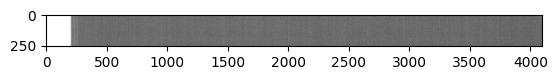

In [4]:
ok_files = sorted(os.listdir('./datasets/NODefect_images/2306881-210020u'))
ng_files = sorted(os.listdir('./datasets/Defect_images'))

ok_bgr = cv2.imread(f'./datasets/NODefect_images/2306881-210020u/{ok_files[0]}')
ok_rgb = cv2.cvtColor(ok_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(ok_rgb)

### 샘플 이미지 생성

In [14]:
import os
import glob
import shutil
import random
import string

random.seed(0)

src_dirs = ['datasets/NODefect_images', 'datasets/Defect_images']
dst_dir = 'datasets/1'
os.makedirs(dst_dir, exist_ok=True)

all_images = []
for d in src_dirs:
    all_images.extend(glob.glob(os.path.join(d, '*.png')))

sample = random.sample(all_images, k=int(len(all_images) * 0.2))

def random_barcode(n=16):
    chars = string.ascii_letters + string.digits
    return ''.join(random.choices(chars, k=n))

for src in sample:
    dst = os.path.join(dst_dir, random_barcode() + '.png')
    while os.path.exists(dst):
        dst = os.path.join(dst_dir, random_barcode() + '.png')
    shutil.copy2(src, dst)

files = os.listdir(dst_dir)
print(len(files))
for f in files[:3]:
    print(f)


21
035HyRrY03K6JBO9.png
1qXIaSyZPaE1pu1l.png
2EtCY2Yl9NfS9yQt.png


In [21]:
import cv2
import os
import glob
import random

random.seed(0)

os.makedirs('datasets/2/OK', exist_ok=True)
os.makedirs('datasets/2/FAIL', exist_ok=True)

def save_patches(src_dir, dst_dir):
    idx = 0
    for path in sorted(glob.glob(os.path.join(src_dir, '**', '*.png'), recursive=True)):
        img = cv2.imread(path)
        h, w = img.shape[:2]
        n = w // h
        if n == 0:
            continue
        patches = [img[:, i*h:(i+1)*h] for i in range(n)]
        k = int(len(patches) * 0.2)
        if k == 0:
            continue
        for patch in random.sample(patches, k):
            cv2.imwrite(os.path.join(dst_dir, f'{idx}.png'), patch)
            idx += 1
    return idx

save_patches('datasets/NODefect_images', 'datasets/2/OK')
save_patches('datasets/Defect_images', 'datasets/2/FAIL')

print(len(os.listdir('datasets/2/OK')), len(os.listdir('datasets/2/FAIL')))

first = sorted(os.listdir('datasets/2/OK'))[0]
img = cv2.imread(os.path.join('datasets/2/OK', first))
print(img.shape)


423 317
(256, 256, 3)


In [22]:
import cv2
import os
import glob
import random

random.seed(0)

PATCH_SIZE = 256
SAMPLE_RATE = 0.2

os.makedirs('datasets/3/OK', exist_ok=True)
os.makedirs('datasets/3/FAIL', exist_ok=True)

def save_patches(src_dir, dst_dir):
    idx = 0

    for path in sorted(glob.glob(os.path.join(src_dir, '**', '*.png'), recursive=True)):
        img = cv2.imread(path)

        if img is None:
            continue

        h, w = img.shape[:2]
        patches = []

        for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
            for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
                patch = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                patches.append(patch)

        k = int(len(patches) * SAMPLE_RATE)

        if k == 0:
            continue

        for patch in random.sample(patches, k):
            cv2.imwrite(os.path.join(dst_dir, f'{idx}.png'), patch)
            idx += 1

    return idx

ok_count = save_patches('datasets/NODefect_images', 'datasets/3/OK')
fail_count = save_patches('datasets/Defect_images', 'datasets/3/FAIL')

print(len(os.listdir('datasets/3/OK')))
print(len(os.listdir('datasets/3/FAIL')))

ok_files = sorted(os.listdir('datasets/3/OK'))

if len(ok_files) > 0:
    first = ok_files[0]
    img = cv2.imread(os.path.join('datasets/3/OK', first))
    print(img.shape)
else:
    print('datasets/3/OK 폴더에 저장된 patch가 없습니다.')

423
317
(256, 256, 3)


### 1단계 샘플 이미지 (데이터 확인)

In [5]:
ok_files = sorted(os.listdir('datasets/3/OK'))
path = f'datasets/3/OK/{ok_files[0]}'
print(path)

datasets/3/OK/0.png


In [6]:
img_bgr = cv2.imread(path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb.shape

(256, 256, 3)

In [7]:
from torchvision import transforms
from PIL import Image

In [8]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

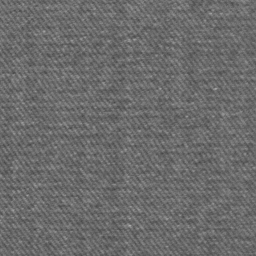

In [12]:
img_pil = Image.fromarray(img_rgb)
img_pil

In [13]:
t = transform(img_pil)
t.shape

torch.Size([3, 224, 224])

In [15]:
import os, glob, torch
import cv2
from torch.utils.data import dataset
from PIL import Image

class FabricDataset(dataset.Dataset):
    #data/2의 OK/FAIL 이미지를 학습 데이터로 제공
    def __init__(self, root, transform):
        self.files = []
        self.labels = []
        for path in glob.glob(f'{root}/OK/*.png'):
            self.files.append(path)
            self.labels.append(0)
        for path in glob.glob(f'{root}/FAIL/*.png'):
            self.files.append(path)
            self.labels.append(1)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        # cv2로 읽으면 BGR -> RGB -> PIL -> transform
        img_bgr = cv2.imread(self.files[i])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        x = self.transform(img_pil)
        y = float(self.labels[i])
        return x, y

In [16]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = FabricDataset('datasets/3', transform)

In [17]:
x, y = dataset[0]
x.shape, y

(torch.Size([3, 224, 224]), 0.0)

### 배치 구조 데이터 준비

In [18]:
from torch.utils.data import DataLoader, random_split
torch.manual_seed(33)

n_total = len(dataset)
n_train = int(n_total * 0.7)
n_valid = n_total - n_train
train_set, valid_set = random_split(dataset, [n_train, n_valid])
print(n_total, n_train, n_valid)

740 518 222


In [19]:
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=16, shuffle=True)

In [21]:
t = next(iter(train_loader))
print(t[0].shape)

torch.Size([16, 3, 224, 224])


### 딥러닝 모델 설계 (신경망 구축)

In [22]:
import torch.nn as nn

model_v1 = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1), # 채널 3 -> 16
    nn.ReLU(),
    nn.MaxPool2d(2), # 2x2 Max Pooling, 차원 224 -> 112
    nn.Conv2d(16, 32, kernel_size=3, padding=1), # 채널 16 -> 32
    nn.ReLU(),
    nn.MaxPool2d(2), # 2x2 Max Pooling, 차원 112 -> 56
    nn.Flatten(), # 32*56*56 -> 100352
    nn.Linear(32*56*56, 1) # 출력 (1,) -> 0 : OK, 1 : FAIL
)

print(model_v1)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=100352, out_features=1, bias=True)
)


In [23]:
def train_epoch(model, loader, loss_fn, optimizer):
    # 학습 데이터 한 바퀴 + 파라미터 업데이트
    model.train() # model.nograd() -> 학습 안함
    total_loss, total_corret, total = 0, 0, 0
    for x, y in loader:
        optimizer.zero_grad() # 기울기 초기화
        logit = model(x).squeeze(1) # 학습해서 차원 하나로 변경
        loss = loss_fn(logit, y)
        loss.backward()  # 역전파(기울기 계산)
        optimizer.step() # 파라미터 업데이트
        total_loss += loss.item() * x.size(0) # 배치 손실 합산
        pred = (torch.sigmoid(logit) > 0.5).float() # 예측값 계산
        total_corret += (pred == y).sum().item() # 맞춘 개수
        total += x.size(0) # 총 개수

    return total_loss / total, total_corret / total

In [27]:
def valid_epoch(model, loader, loss_fn):
    # 검증 (파라미터 업데이트 안함)
    model.eval() # 검증모드 활성화
    total_loss, total_corret, total = 0, 0, 0
    with torch.no_grad(): # 검증에서는 기울기 계산 안함
        for x, y in loader:
            logit = model(x).squeeze(1) # 차원 하나로 변경
            loss = loss_fn(logit, y)
            total_loss += loss.item() * x.size(0) # 배치 손실 합산
            pred = (torch.sigmoid(logit) > 0.5).float() # 예측값 계산
            total_corret += (pred == y).sum().item() # 맞춘 개수
            total += x.size(0) # 총 개수

    return total_loss / total, total_corret / total

In [28]:
loss_fn = nn.BCEWithLogitsLoss() # 이진 분류 손실 함수(바이너리 크로스 엔트로피)
optimizer = torch.optim.Adam(model_v1.parameters(), lr = 0.0001)


In [29]:
train_losses_v1, train_accs_v1, valid_losses_v1, valid_accs_v1 = [], [], [], []
EPOCHS = 10
print('1차 학습 진행')
for epoch in range(EPOCHS+1):
    tr_loss, tr_acc = train_epoch(model_v1, train_loader, loss_fn, optimizer)
    va_loss, va_acc = valid_epoch(model_v1, valid_loader, loss_fn)
    train_losses_v1.append(tr_loss)
    train_accs_v1.append(tr_acc)
    valid_losses_v1.append(va_loss)
    valid_accs_v1.append(va_acc)
    print(f'Epoch {epoch:2d} | train Loss {tr_loss:.4f} acc {tr_acc:.4f}')
    print(f'valid Loss {va_loss:.4f} Acc {va_acc:.4f}')


1차 학습 진행
Epoch  0 | train Loss 0.6533 acc 0.6274
valid Loss 0.6767 Acc 0.5631
Epoch  1 | train Loss 0.6240 acc 0.6274
valid Loss 0.6582 Acc 0.6126
Epoch  2 | train Loss 0.6043 acc 0.6467
valid Loss 0.6664 Acc 0.6081
Epoch  3 | train Loss 0.5844 acc 0.6892
valid Loss 0.6706 Acc 0.6126
Epoch  4 | train Loss 0.5854 acc 0.6834
valid Loss 0.6748 Acc 0.5946
Epoch  5 | train Loss 0.5821 acc 0.6834
valid Loss 0.6619 Acc 0.6126
Epoch  6 | train Loss 0.5620 acc 0.7066
valid Loss 0.6550 Acc 0.6216
Epoch  7 | train Loss 0.5552 acc 0.7220
valid Loss 0.6507 Acc 0.6261
Epoch  8 | train Loss 0.5534 acc 0.7046
valid Loss 0.6801 Acc 0.6036
Epoch  9 | train Loss 0.5576 acc 0.7201
valid Loss 0.6574 Acc 0.6261
Epoch 10 | train Loss 0.5304 acc 0.7413
valid Loss 0.6434 Acc 0.6396


train과 valid간의 loss/acc 차이가 적을 수록 좋다

In [30]:
# 저장
torch.save(model_v1.state_dict(), 'fabric_cnn_v1.pth')

In [32]:
os.path.getsize('fabric_cnn_v1.pth') / 1024

414.9658203125

### 혼동행렬
- 재현율
- 정밀도


In [33]:
from torchvision import models
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [34]:
model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\UserK/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100.0%


In [35]:
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

In [39]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

batch_seize = 16
    

In [42]:
train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
# 검증 데이터는 증강 금지
valid_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])




In [43]:
full_train = FabricDataset('datasets/3', train_transform)
full_valid = FabricDataset('datasets/3', valid_transform)

In [45]:
# 학습/검증 데이터 분할
n_total = len(full_train)
n_train = int(n_total * 0.7)
indices = list(range(n_total))

In [46]:
from torch.utils.data import Subset
import random

random.seed(33)
random.shuffle(indices)
train_idx, valid_idx = indices[:n_train], indices[n_train:]
train_set2 = Subset(full_train, train_idx)
valid_set2 = Subset(full_valid, valid_idx)

train_loader2 = DataLoader(train_set2, batch_size=batch_seize, shuffle=True)
valid_loader2 = DataLoader(valid_set2, batch_size=batch_seize, shuffle=False)


### 모델 학습

In [51]:
EPOCHS = 5
for epoch in range(EPOCHS+1):
    # 학습
    model.train()
    for x, y in train_loader2:
        optimizer.zero_grad()
        y = y.float()
        output = model(x)
        logit = output.logits.squeeze(1)
        loss = loss_fn(logit, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    # 검증
    model.eval()
    with torch.no_grad():
        total_loss, total_correct, total = 0, 0, 0
        for x, y in valid_loader2:
            y = y.float()
            output = model(x)
            if hasattr(output, 'logits'):
                logit = output.logits.squeeze(1)
            else:
                logit = output.squeeze(1)
            loss = loss_fn(logit, y)
            total_loss += loss.item() * x.size(0)
            pred = (torch.sigmoid(logit) > 0.5).float()
            total_correct += (pred == y).sum().item()
            total += x.size(0)
